# Chest X-Ray Classification with a Convolutional Neural Network

**Project type :** Computer Vision / Deep Learning / Medical Image Classification  
**Framework :** PyTorch  
**Primary task :** Binary classification of chest X-ray images into `NORMAL` and `PNEUMONIA`.

## Project overview

In this notebook I develop a convolutional neural network (CNN) for chest X-ray classification and, importantly, I treat the model as an **experimental mathematical object** rather than a black box. I progressively modify the training pipeline and architecture to study how **data augmentation, batch normalization, optimization, and L1 regularization** affect learning stability and generalization.

The project follows an experimental workflow:

1. inspect the image dataset and class distribution;
2. construct reproducible preprocessing pipelines;
3. design a CNN from first principles;
4. train and evaluate a baseline model;
5. introduce data augmentation;
6. introduce batch normalization;
7. introduce an L1 regularization term;
8. compare the resulting learning curves and test performance.

Convolution is treated as a parameterized linear operator on tensors, ReLU as a nonlinear map, pooling as a spatial downsampling operator, batch normalization as an affine normalization of feature channels, and training as numerical minimization of an empirical risk using stochastic gradient descent.

## Skills

**Python · PyTorch · CNNs · Computer Vision · Image preprocessing · Data augmentation · Batch Normalization · SGD with momentum · Learning-rate scheduling · L1 regularization · Numerical optimization · Tensor-shape analysis · Mathematical modeling**

## 1. Imports and computational environment

The next cell imports the numerical, image-processing, visualization, and deep-learning tools used throughout the project.

- **NumPy** provides numerical array operations.
- **OpenCV** is available for computer-vision/image-processing operations.
- **Matplotlib** is used to visualize images and learning curves.
- **PyTorch** provides tensors, automatic differentiation, neural-network modules, optimization, and GPU/MPS support.

In [1]:
# Data set Download : https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images
import os
import numpy as np
import cv2

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn

### Installing an auxiliary inspection tool

`torchsummary` is used later to inspect the CNN. A model summary is useful because it makes the architecture quantitative: it exposes the input/output tensor dimensions and the number of trainable parameters instead of leaving the network as an abstract collection of layers.

In [2]:
pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


### Dataset location

The dataset path specification : the expected directory structure is the one supported by `torchvision.datasets.ImageFolder`:

```text
chest_xray/
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── test/
    ├── NORMAL/
    └── PNEUMONIA/
```

In [3]:
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
from torchsummary import summary
from tqdm import tqdm

# Root directory containing the ImageFolder-compatible dataset.
data_path = '/Users/chamirmbembe/Downloads/PyTorch_CV/chest_xray'

# 2. Data exploration

Before defining a neural network, it is important to understand the statistical object on which it will operate. Here I inspect the available files and class distribution. This is a basic but essential machine-learning principle: model architecture and evaluation should be interpreted in the context of the dataset.

The helper function below retrieves the filenames from each class directory. Conceptually, the dataset is a finite sample

$$
\mathcal D=\{(x_i,y_i)\}_{i=1}^N,
\qquad
x_i\in\mathbb R^{H\times W\times C},\quad
y_i\in\{0,1\}.
$$

$$H\text{ for height, }W \text{ for width, }C\text{ for channel}$$

Separating the directories allows us to inspect the empirical class distribution before training.

In [4]:
# Class labels used by the directory structure.
class_name = ['NORMAL','PNEUMONIA']

def get_list_files(dirName):
    '''
    input - directory location
    output - list the files in the directory
    '''
    files_list = os.listdir(dirName)
    return files_list

files_list_normal_train = get_list_files(data_path + '/train/'+class_name[0])
files_list_pneu_train   = get_list_files(data_path + '/train/'+class_name[1])
files_list_normal_test  = get_list_files(data_path + '/test/'+class_name[0])
files_list_pneu_test    = get_list_files(data_path + '/test/'+class_name[1])

The following cell reports the number of images in each split and class. In the supplied notebook the dataset contains **5232 training images** (1349 normal and 3883 pneumonia) and **625 test images** (235 normal and 390 pneumonia). The class distribution is therefore not balanced, so accuracy alone should not be treated as a complete clinical evaluation metric.

In [5]:
print(f"Number of train samples in NORMAL category    : {len(files_list_normal_train)}")
print(f"Number of train samples in PNEUMONIA category : {len(files_list_pneu_train)}")
print(f"Number of test samples in NORMAL category     : {len(files_list_normal_test)}")
print(f"Number of test samples in PNEUMONIA category  : {len(files_list_pneu_test)}")

Number of train samples in NORMAL category    : 1349
Number of train samples in PNEUMONIA category : 3883
Number of test samples in NORMAL category     : 235
Number of test samples in PNEUMONIA category  : 390


### Visual sanity check

A random image from each class is displayed together with its original array shape. This step checks an important assumption: chest X-rays may arrive with different spatial dimensions and channel conventions, so the preprocessing pipeline must map heterogeneous raw images into a common tensor representation.

The visualization also gives qualitative intuition for the classification problem before any learned representation is introduced.

 The shape of the image (2175, 1974)


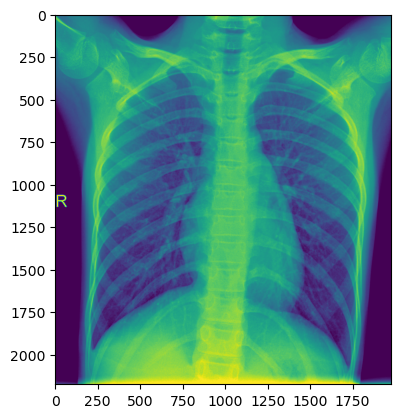

 The shape of the image (664, 960)


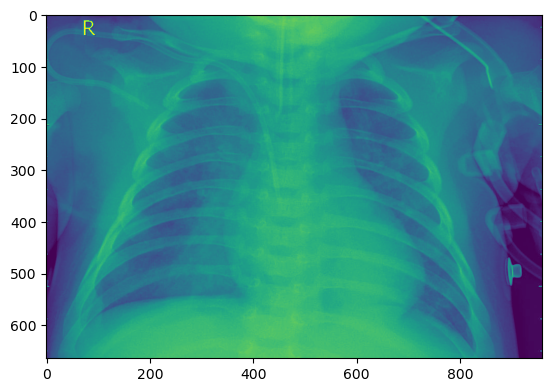

In [6]:
# Randomly sample one training example from both the NORMAL and the PNEUMONIA classes for visual inspection.
rand_img_no = np.random.randint(0,len(files_list_normal_train))

# Print a random NORMAL train image
img = data_path + '/train/NORMAL/'+ files_list_normal_train[rand_img_no]
print(f" The shape of the image {plt.imread(img).shape}")
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

# Print a random PNEUMONIA train image
img = data_path + '/train/PNEUMONIA/'+ files_list_pneu_train[rand_img_no]
print(f" The shape of the image {plt.imread(img).shape}")
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

# 3. Data loading and preprocessing

Neural networks require tensors with a consistent shape. The transformation pipeline therefore maps each image to a $224\times224$ spatial grid, converts it to a PyTorch tensor, and normalizes its channels.

The normalization

$$
x'_{c}=\frac{x_c-\mu_c}{\sigma_c}
$$

is applied channel-wise. The values used here are the standard ImageNet normalization statistics,

$$
\mu=(0.485,0.456,0.406),\qquad
\sigma=(0.229,0.224,0.225).
$$

Although the network is trained from scratch here, this normalization convention is widely used in computer vision and makes the numerical scale of the input more controlled.

In [7]:
# Deterministic preprocessing: resize -> crop -> tensor -> channel-wise normalization.
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

`ImageFolder` converts the directory structure into labeled examples, while `DataLoader` turns the dataset into mini-batches.

For training, the batch size is $16$. Thus one optimization step operates on

$$
X\in\mathbb R^{16\times 224\times 224\times 3}
$$

in the usual case. The test loader uses batch size $1$, making the evaluation loop straightforward.

Shuffling the training set approximates sampling different mini-batches from the empirical distribution, which is the basis of stochastic gradient descent.

In [8]:
# ImageFolder maps directory names to integer class labels; DataLoader creates mini-batches.
train_data = datasets.ImageFolder(os.path.join(data_path, 'train'), transform= train_transform)
test_data  = datasets.ImageFolder(os.path.join(data_path, 'test'), transform= test_transform)

train_loader = DataLoader(train_data,
                          batch_size= 16, 
                          shuffle= True, 
                          pin_memory= True)
test_loader = DataLoader(test_data,
                         batch_size= 1, 
                         shuffle= False, 
                         pin_memory= True)

This cell verifies the class names and the number of examples actually seen by the PyTorch dataset objects. Keeping these checks close to the data-loading code makes the notebook easier to audit and reproduce.

In [9]:
class_names = train_data.classes
print(class_names)
print(f'Number of train images : {len(train_data)}')
print(f'Number of test images  : {len(test_data)}')

['NORMAL', 'PNEUMONIA']
Number of train images : 5232
Number of test images  : 626


# 4. Baseline CNN architecture

The first model is a compact CNN designed manually rather than imported from a pretrained architecture. 

A convolutional layer implements a local linear transformation. For an input feature map $X$, a simplified single-output-channel expression is

$$
Y_{i,j}
=
\sum_{c=1}^{C_{\mathrm{in}}}
\sum_{u,v}
W_{c,u,v}\,X_{c,i+u,j+v}.
$$

The convolution is followed by the nonlinear activation

$$
\operatorname{ReLU}(z)=\max(0,z),
$$

which is essential because a composition of linear maps alone would still be linear.

The network progressively changes the number of channels while pooling reduces the spatial resolution. The final convolution produces two class scores, corresponding to `NORMAL` and `PNEUMONIA`.

In [10]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Input Block
        self.convblock1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, 
                      kernel_size=(3, 3),
                      padding=0, bias=False),
            nn.ReLU()
        )
        self.pool11 = nn.MaxPool2d(2, 2)
        
        # CONVOLUTION BLOCK
        self.convblock2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, 
                      kernel_size=(3, 3), 
                      padding=0, bias=False),
            nn.ReLU()
        )
        # TRANSITION BLOCK : Because the convolutional layer reduces the number of channel
        self.pool22 = nn.MaxPool2d(2, 2)
        
        self.convblock3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=10, 
                      kernel_size=(1, 1), 
                      padding=0, bias=False),
            nn.ReLU()
        )
        self.pool33 = nn.MaxPool2d(2, 2)
        
        # CONVOLUTION BLOCK
        self.convblock4 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, 
                      kernel_size=(3, 3), 
                      padding=0, bias=False),
            nn.ReLU()
        )
        
        self.convblock5 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=32, 
                      kernel_size=(1, 1), 
                      padding=0, bias=False),
            nn.ReLU()
        )
        
        self.convblock6 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=10, 
                      kernel_size=(1, 1), 
                      padding=0, bias=False),
            nn.ReLU()
        )

        self.convblock7 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, 
                      kernel_size=(3, 3), 
                      padding=0, bias=False),
            nn.ReLU()
        )
        
        self.convblock8 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=32, 
                      kernel_size=(1, 1), 
                      padding=0, bias=False),
            nn.ReLU()
        )
        
        self.convblock9 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=10, 
                      kernel_size=(1, 1), 
                      padding=0, bias=False),
            nn.ReLU()
        )
        
        self.convblock10 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=14, 
                      kernel_size=(3, 3), 
                      padding=0, bias=False),
            nn.ReLU()
        )
        
        self.convblock11 = nn.Sequential(
            nn.Conv2d(in_channels=14, out_channels=16, 
                      kernel_size=(3, 3), 
                      padding=0, bias=False),
            nn.ReLU()
        )

        # OUTPUT BLOCK
        self.gap = nn.Sequential(
            nn.AvgPool2d(kernel_size=4)
        )
        
        self.convblockout = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=2, 
                      kernel_size=(4, 4), 
                      padding=0, bias=False),
        )
    def forward(self, x):
        x = self.convblock1(x)
        x = self.pool11(x)
        x = self.convblock2(x)
        x = self.pool22(x)
        x = self.convblock3(x)
        x = self.pool33(x)
        x = self.convblock4(x)
        x = self.convblock5(x)
        x = self.convblock6(x)
        x = self.convblock7(x)
        x = self.convblock8(x)
        x = self.convblock9(x)
        x = self.convblock10(x)
        x = self.convblock11(x)
        x = self.gap(x)
        x = self.convblockout(x)
        x = x.view(-1, 2)
        return F.log_softmax(x, dim=-1)

#### Tensor flow through the baseline `Net`

This section is intentionally detailed because it shows exactly how a single input image becomes a classification output.

The preprocessed image is represented by a tensor

$$
x\in\mathbb R^{3\times224\times224},
$$

where the **3 channels** correspond to the RGB representation produced by `ToTensor`. A batch of $16$ images therefore has shape

$$
(16,3,224,224).
$$

For convolution without padding and stride $1$, the spatial size changes according to

$$
H_{\mathrm{out}}=H_{\mathrm{in}}-K+1,
\qquad
W_{\mathrm{out}}=W_{\mathrm{in}}-K+1,
$$
Where $H$ is the height, $W$ is the width and $K$ is the kernel size. 

For max/average pooling with kernel $2$ and stride $2$, the spatial dimensions are approximately halved. Applying the actual operations in this model gives the following chain for one image:

| Stage | Operation | Channels | Spatial size | Trainable parameters |
|---|---|---:|---:|---:|
| Input | image tensor | $3$ | $224\times 224$ | $0$ |
| 1 | $3\to 8$, $3\times 3$ conv + ReLU | $8$ | $222\times 222$ | $3\cdot 8\cdot 3^2=216$ |
| 2 | $2\times 2$ max-pool | $8$ | $111\times 111$ | $0$ |
| 3 | $8\to 16, 3\times 3$ conv + ReLU | $16$ | $109\times 109$ | $8\cdot 16\cdot 3^2=1152$ |
| 4 | $2\times 2$ max-pool | $16$ | $54\times 54$ | $0$ |
| 5 | $16\to 10, 1\times 1$ conv + ReLU | $10$ | $54\times 54$ | $16\cdot 10=160$ |
| 6 | $2\times 2$ max-pool | $10$ | $27\times 27$ | $0$ |
| 7 | $10\to 10, 3\times 3$ conv + ReLU | $10$ | $25\times 25$ | $10\cdot 10\cdot 3^2=900$ |
| 8 | $10\to 32, 1\times 1$ conv + ReLU | $32$ | $25\times 25$ | $10\cdot 32=320$ |
| 9 | $32\to 10, 1\times 1$ conv + ReLU | $10$ | $25\times 25$ | $32\cdot 10=320$ |
| 10 | $10\to 10, 3\times 3$ conv + ReLU | $10$ | $23\times 23$ | $10\cdot 10\cdot 3^2=900$ |
| 11 | $10\to 32, 1\times 1$ conv + ReLU | $32$ | $23\times 23$ | $10\cdot 32=320$ |
| 12 | $32\to 10, 1\times 1$ conv + ReLU | $10$ | $23\times 23$ | $32\cdot 10=320$ |
| 13 | $10\to 14, 3\times 3$ conv + ReLU | $14$ | $21\times 21$ | $10\cdot 14\cdot 3^2=1260$ |
| 14 | $14\to 16, 3\times 3$ conv + ReLU | $16$ | $19\times 19$ | $14\cdot 16\cdot 3^2=2016$ |
| 15 | $4\times 4$ average pool, stride $4$ | $16$ | $4\times 4$ | $0$ |
| 16 | $16\to 2$, $4\times 4$ conv | $2$ | $1\times 1$ | $16\cdot 2\cdot 4^2=512$ |
| Output | flatten + log-softmax | $2$ | two class log-probabilities | $0$ |

Because `bias=False` is used in every convolution, the convolutional parameter count is simply

$$
\sum_{\ell} C_{\mathrm{out}}^{(\ell)}
C_{\mathrm{in}}^{(\ell)}
K_\ell^2
=8396.
$$

Thus the baseline network has **8,396 trainable parameters**.

The $1\times1$ convolutions are especially interesting mathematically: at each spatial position they implement a learned linear map

$$
\mathbb R^{C_{\mathrm{in}}}\longrightarrow
\mathbb R^{C_{\mathrm{out}}},
$$

without directly mixing neighbouring pixels. They therefore act as channel-mixing or dimensionality-changing operators.

Finally, the $2$-channel output is converted into log-probabilities using

$$
\log\operatorname{softmax}(z)_k
=
z_k-\log\left(\sum_j e^{z_j}\right).
$$

This is paired with negative log-likelihood loss during training.

### Device selection and architecture inspection

The next cell places the model on an available accelerator when possible. PyTorch tensors and model parameters must reside on the same device for the forward and backward computations.

`torchsummary` is then used to inspect the architecture. This is useful both computationally and mathematically: the summary verifies that the tensor dimensions compose correctly from the input space 
$$\mathbb R^{3\times224\times224}$$
to the final two-dimensional class space.

In [11]:
# Instantiate a fresh model so the experiment starts from a new parameter initialization.
# We put the model in a GPU if anyone is available
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(f"Available processor {device}")
model = Net().to(device)
summary(model, input_size=(3, 224, 224))

Available processor cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             216
              ReLU-2          [-1, 8, 222, 222]               0
         MaxPool2d-3          [-1, 8, 111, 111]               0
            Conv2d-4         [-1, 16, 109, 109]           1,152
              ReLU-5         [-1, 16, 109, 109]               0
         MaxPool2d-6           [-1, 16, 54, 54]               0
            Conv2d-7           [-1, 10, 54, 54]             160
              ReLU-8           [-1, 10, 54, 54]               0
         MaxPool2d-9           [-1, 10, 27, 27]               0
           Conv2d-10           [-1, 10, 25, 25]             900
             ReLU-11           [-1, 10, 25, 25]               0
           Conv2d-12           [-1, 32, 25, 25]             320
             ReLU-13           [-1, 32, 25, 25]               0
           Conv

# 5. Training objective and optimization

The training phase minimizes an empirical loss over the labeled dataset. If $$f_\theta(x)$$ denotes the network with parameters $\theta$, the basic objective is

$$
\widehat R(\theta)
=
\frac1N\sum_{i=1}^{N}
\ell\big(f_\theta(x_i),y_i\big).
$$

Here the loss is PyTorch's negative log-likelihood loss, appropriate because the network outputs log-probabilities.

The optimization algorithm is stochastic gradient descent with momentum:

$$
v_t=\mu v_{t-1}+\nabla_\theta \widehat R_t(\theta_t),
\qquad
\theta_{t+1}=\theta_t-\eta v_t.
$$

We also uses `StepLR`, which reduces the learning rate by a factor of $0.5$ every six epochs. This is a simple form of learning-rate scheduling intended to allow larger exploratory steps early in training and smaller updates later.

In [12]:
# Fresh metric containers for an independent experiment.
train_losses = []
test_losses  = []
train_acc    = []
test_acc     = []

The `train` function implements one epoch of stochastic optimization.

The sequence is:

1. put the model in training mode;
2. transfer the mini-batch to the selected device;
3. clear old gradients;
4. compute the forward pass $f_\theta(X)$;
5. compute the loss;
6. call `backward()` to compute $\nabla_\theta\ell$ through automatic differentiation;
7. update the parameters using the optimizer;
8. compute running classification accuracy.

PyTorch's autograd system constructs the computational graph during the forward pass and applies the chain rule during `loss.backward()`. Thus the mathematical gradient

$$
\frac{\partial \ell}{\partial\theta}
$$

is obtained automatically even though the network contains many nested nonlinear operations.

In [13]:
# One epoch of mini-batch stochastic optimization.
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    pbar = tqdm(train_loader)
    correct = 0
    processed = 0
    for batch_idx, (data, target) in enumerate(pbar):
        # get data
        data, target = data.to(device), target.to(device)
       
        # Initialization of gradient
        optimizer.zero_grad()
       
        # prediction on data
        y_pred = model(data)
        
        # Calculating loss given the prediction
        loss = F.nll_loss(y_pred, target)
        train_losses.append(loss)
        
        # Backprop
        loss.backward()
        optimizer.step()
        
        # get the index of the log-probability corresponding to the max value
        pred = y_pred.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        processed += len(data)
        
        pbar.set_description(desc= f"Loss={loss.item()} Batch_id={batch_idx} Accuracy={100*correct/processed}")
        train_acc.append(100*correct/processed)

def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target,
            reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(test_loss, correct, len(test_loader.dataset), 100. * correct / len(test_loader.dataset)))
    test_acc.append(100. * correct / len(test_loader.dataset))

The baseline experiment initializes the CNN, SGD optimizer, and learning-rate scheduler. Fifteen epochs are used.

The key experimental principle is **controlled comparison**: later variations should change one important ingredient while keeping the remainder of the training protocol as comparable as possible.

In [14]:
# Instantiate a fresh model so the experiment starts from a new parameter initialization.
model = Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01,
momentum=0.9)
scheduler = StepLR(optimizer, step_size=6, gamma=0.5)

EPOCHS = 15
for epoch in range(EPOCHS):
    print("EPOCH:", epoch)
    train(model, device, train_loader, optimizer, epoch)
    scheduler.step()
    print('current Learning Rate: ', optimizer.state_dict()["param_groups"][0]["lr"])
    test(model, device, test_loader)

EPOCH: 0


  0%|                                                   | 0/327 [00:00<?, ?it/s]/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Loss=0.6931467652320862 Batch_id=326 Accuracy=34.461009174311926: 100%|█| 327/32


current Learning Rate:  0.01

Test set: Average loss: 0.6931, Accuracy: 325/626 (51.92%)

EPOCH: 1


Loss=0.6931468844413757 Batch_id=326 Accuracy=48.01223241590214: 100%|█| 327/327


current Learning Rate:  0.01

Test set: Average loss: 0.6931, Accuracy: 406/626 (64.86%)

EPOCH: 2


...

current Learning Rate:  0.0025

Test set: Average loss: 0.6931, Accuracy: 390/626 (62.30%)

EPOCH: 13


Loss=0.6931232810020447 Batch_id=326 Accuracy=74.21636085626912: 100%|█| 327/327


current Learning Rate:  0.0025

Test set: Average loss: 0.6931, Accuracy: 390/626 (62.30%)

EPOCH: 14


Loss=0.6931256651878357 Batch_id=326 Accuracy=74.21636085626912: 100%|█| 327/327


current Learning Rate:  0.0025

Test set: Average loss: 0.6931, Accuracy: 390/626 (62.30%)



The plots below convert the recorded tensors and lists into ordinary numerical arrays and visualize training loss, training accuracy, test loss, and test accuracy. We interpret these four curves together. 

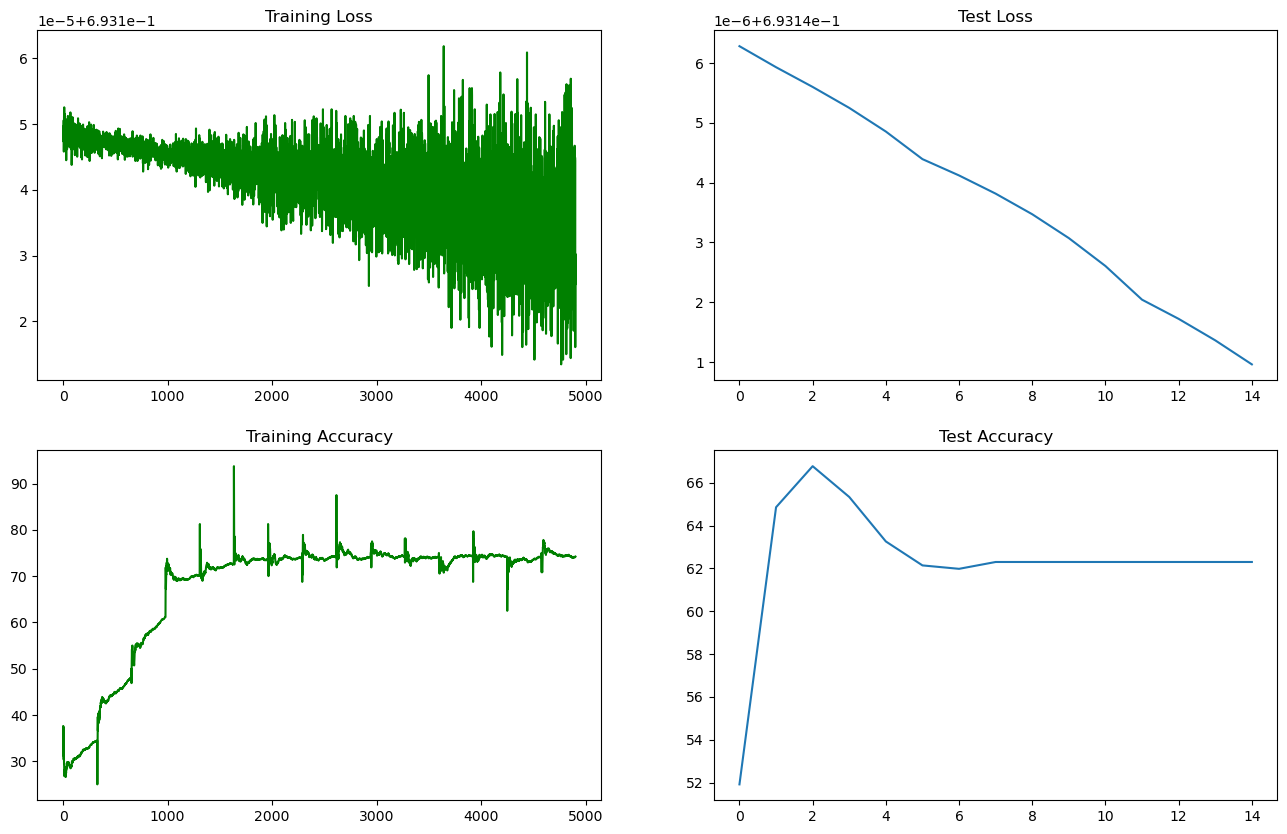

In [15]:
train_losses = [float(i.cpu().detach().numpy()) for i in train_losses]
train_acc    = [i for i in train_acc]
test_losses  = [i for i in test_losses]
test_acc     = [i for i in test_acc]

fig, axs = plt.subplots(2,2,figsize=(16,10))

axs[0, 0].plot(train_losses, color='green')
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc, color='green')
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(test_losses)
axs[0, 1].set_title("Test Loss")
axs[1, 1].plot(test_acc)
axs[1, 1].set_title("Test Accuracy")

plt.show()

### Baseline interpretation

The first experiment provides an intentionally imperfect reference point. In the recorded run, the model remained around **62.3% test accuracy** for much of the training process. The important lesson is not simply that the baseline performs poorly, but that this establishes a quantitative reference against which the subsequent architectural and regularization changes can be evaluated.

 The training loss shows that the model is tremendously unstable.

# 6. Second variation : Data Augmentation

The next experiment changes the **training data distribution** rather than the CNN architecture.

The training pipeline introduces:

- small brightness/contrast/saturation/hue perturbations;
- random horizontal flips;
- random rotations up to $10^\circ$.

The underlying idea is to replace the empirical distribution $P_{\mathcal D}$ by a transformed distribution generated from plausible image-preserving transformations. If $T$ is a random augmentation, training approximately minimizes

$$
\mathbb E_{(x,y)\sim\mathcal D}
\mathbb E_T
\left[
\ell(f_\theta(Tx),y)
\right].
$$

This can reduce over-reliance on incidental pixel patterns and encourage the model to learn features that are more invariant to small transformations.

Only the **training** images receive random augmentation. The test pipeline remains deterministic so that test performance measures the same fixed evaluation distribution each time.

This separation is fundamental: augmentation is a training-time regularization mechanism, not a modification of the evaluation target.

In [16]:
# Training-time augmentation: perturb appearance and geometry while preserving the label.
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ColorJitter(brightness=0.10, contrast=0.1,
                           saturation=0.10, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

The dataset and loaders are rebuilt so that the new transformation pipeline is actually applied when samples are drawn. The architecture, optimizer settings, batch size, and number of epochs remain otherwise comparable to the baseline experiment.

In [17]:
# ImageFolder maps directory names to integer class labels; DataLoader creates mini-batches.
train_data = datasets.ImageFolder(os.path.join(data_path, 'train'), transform= train_transform)
test_data  = datasets.ImageFolder(os.path.join(data_path, 'test'), transform= test_transform)

train_loader = DataLoader(train_data,
                          batch_size= 16, 
                          shuffle= True, 
                          pin_memory= True)
test_loader  = DataLoader(test_data,
                         batch_size= 1, 
                         shuffle= False, 
                         pin_memory= True)

Metric containers are reset before the second experiment. This prevents results from the first experiment from contaminating the learning curves of the second experiment.

In [18]:
# Fresh metric containers for an independent experiment.
train_losses = []
test_losses  = []
train_acc    = []
test_acc     = []

The augmented model is trained using the same CNN and optimization configuration. This isolates the effect of data augmentation as much as possible.

In [19]:
# Instantiate a fresh model so the experiment starts from a new parameter initialization.
model = Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01,
momentum=0.9)
scheduler = StepLR(optimizer, step_size=6, gamma=0.5)

EPOCHS = 15
for epoch in range(EPOCHS):
    print("EPOCH:", epoch)
    train(model, device, train_loader, optimizer, epoch)
    scheduler.step()
    print('current Learning Rate: ', optimizer.state_dict()["param_groups"][0]["lr"])
    test(model, device, test_loader)

EPOCH: 0


Loss=0.693145751953125 Batch_id=326 Accuracy=38.952599388379205: 100%|█| 327/327


current Learning Rate:  0.01

Test set: Average loss: 0.6931, Accuracy: 348/626 (55.59%)

EPOCH: 1


Loss=0.6931396126747131 Batch_id=326 Accuracy=72.93577981651376: 100%|█| 327/327


current Learning Rate:  0.01

Test set: Average loss: 0.6931, Accuracy: 399/626 (63.74%)

EPOCH: 2


...

current Learning Rate:  0.0025

Test set: Average loss: 0.7688, Accuracy: 503/626 (80.35%)

EPOCH: 13


Loss=0.014579986222088337 Batch_id=326 Accuracy=93.97935779816514: 100%|█| 327/3


current Learning Rate:  0.0025

Test set: Average loss: 0.6971, Accuracy: 503/626 (80.35%)

EPOCH: 14


Loss=0.10786853730678558 Batch_id=326 Accuracy=93.71177370030581: 100%|█| 327/32


current Learning Rate:  0.0025

Test set: Average loss: 0.4661, Accuracy: 526/626 (84.03%)



The resulting curves allow a direct comparison with the baseline. In the supplied run, augmentation alone did not resolve the instability: the test accuracy remained around **82.0%** at the end of the recorded experiment.

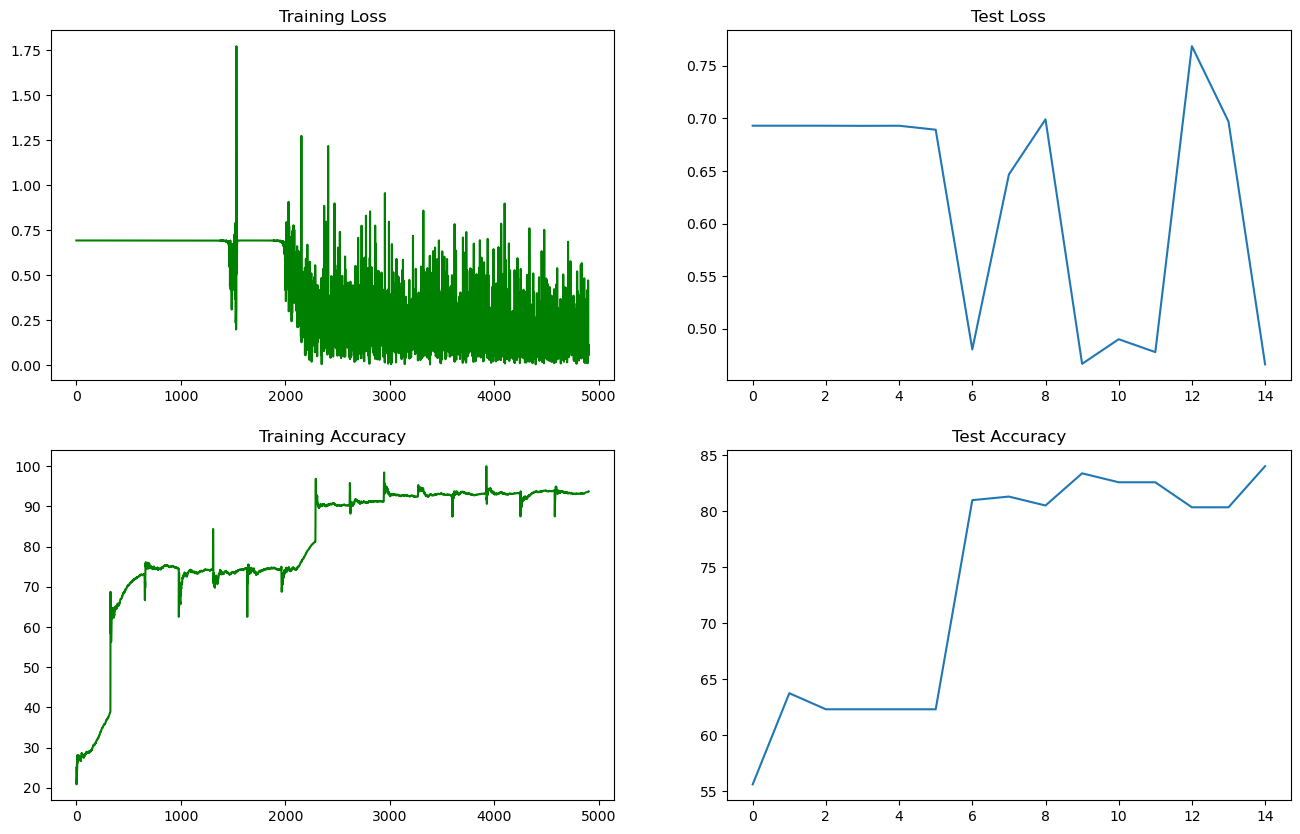

In [20]:
train_losses = [float(i.cpu().detach().numpy()) for i in train_losses]
train_acc    = [i for i in train_acc]
test_losses  = [i for i in test_losses]
test_acc     = [i for i in test_acc]

fig, axs = plt.subplots(2,2,figsize=(16,10))

axs[0, 0].plot(train_losses, color='green')
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc, color='green')
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(test_losses)
axs[0, 1].set_title("Test Loss")
axs[1, 1].plot(test_acc)
axs[1, 1].set_title("Test Accuracy")

plt.show()

The accuracy is still low and the model behaviour is unstable

# 7. Third variation : Batch Normalization

The third experiment modifies the architecture by inserting **Batch Normalization** after each ReLU activation.

For a feature channel, batch normalization computes

$$
\widehat{x}
=
\frac{x-\mu_B}
{\sqrt{\sigma_B^2+\varepsilon}},
\qquad
y=\gamma\widehat{x}+\beta,
$$

where $\mu_B$ and $\sigma_B^2$ are mini-batch statistics and $\gamma,\beta$ are learned parameters.

The purpose is to control the scale of intermediate activations and make optimization better conditioned. It does not merely "normalize the data once"; it dynamically normalizes internal feature distributions during training.

This experiment is particularly useful for illustrating the distinction between **input normalization** and **internal representation normalization**.

In [21]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        # Input Block
        self.convblock1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, 
                      kernel_size=(3, 3),
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(8)
        )
        self.pool11 = nn.MaxPool2d(2, 2)
        
        # CONVOLUTION BLOCK 1
        self.convblock2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, 
                      kernel_size=(3, 3), 
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(16)
        )
        
        self.pool22 = nn.MaxPool2d(2, 2)
        
        self.convblock3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=10, 
                      kernel_size=(1, 1), 
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.pool33 = nn.MaxPool2d(2, 2)
        
        # CONVOLUTION BLOCK 2
        self.convblock4 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, 
                      kernel_size=(3, 3), 
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        
        self.convblock5 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=32, 
                      kernel_size=(1, 1), 
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(32)
        )
        
        self.convblock6 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=10, 
                      kernel_size=(1, 1), 
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )

        self.convblock7 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, 
                      kernel_size=(3, 3), 
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        
        self.convblock8 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=32, 
                      kernel_size=(1, 1), 
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(32)
        )
        
        self.convblock9 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=10, 
                      kernel_size=(1, 1), 
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        
        self.convblock10 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=14, 
                      kernel_size=(3, 3), 
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(14)
        )
        
        self.convblock11 = nn.Sequential(
            nn.Conv2d(in_channels=14, out_channels=16, 
                      kernel_size=(3, 3), 
                      padding=0, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(16)
        )

        # OUTPUT BLOCK
        self.gap = nn.Sequential(
            nn.AvgPool2d(kernel_size=4)
        )
        
        self.convblockout = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=2, 
                      kernel_size=(4, 4), 
                      padding=0, bias=False),
        )
    def forward(self, x):
        x = self.convblock1(x)
        x = self.pool11(x)
        x = self.convblock2(x)
        x = self.pool22(x)
        x = self.convblock3(x)
        x = self.pool33(x)
        x = self.convblock4(x)
        x = self.convblock5(x)
        x = self.convblock6(x)
        x = self.convblock7(x)
        x = self.convblock8(x)
        x = self.convblock9(x)
        x = self.convblock10(x)
        x = self.convblock11(x)
        x = self.gap(x)
        x = self.convblockout(x)
        
        x = x.view(-1, 2)
        return F.log_softmax(x, dim=-1)

The batch-normalized network retains the same convolutional channel structure as the baseline, so the convolutional parameters remain **8,396**. Batch normalization adds two trainable parameters per normalized channel $\gamma$ and $\beta$.

The normalized channel counts are

$$
8+16+10+10+32+10+10+32+10+14+16=158,
$$

so the batch-normalization layers add

$$
2\times158=316
$$

trainable parameters. The resulting total is therefore **8,712 trainable parameters**.

This is a useful example of how a seemingly small architectural change has a precise algebraic cost.

In [22]:
# Fresh metric containers for an independent experiment.
train_losses = []
test_losses  = []
train_acc    = []
test_acc     = []

The third experiment is trained under the same SGD and scheduler configuration. The comparison is therefore primarily about the effect of batch normalization on optimization dynamics and generalization.

In [23]:
# Instantiate a fresh model so the experiment starts from a new parameter initialization.
model = Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01,
momentum=0.9)
scheduler = StepLR(optimizer, step_size=6, gamma=0.5)

EPOCHS = 15
for epoch in range(EPOCHS):
    print("EPOCH:", epoch)
    train(model, device, train_loader, optimizer, epoch)
    scheduler.step()
    print('current Learning Rate: ', optimizer.state_dict()["param_groups"][0]["lr"])
    test(model, device, test_loader)

EPOCH: 0


Loss=0.20590443909168243 Batch_id=326 Accuracy=90.4243119266055: 100%|█| 327/327


current Learning Rate:  0.01

Test set: Average loss: 0.5869, Accuracy: 489/626 (78.12%)

EPOCH: 1


Loss=0.08306045085191727 Batch_id=326 Accuracy=93.96024464831804: 100%|█| 327/32


current Learning Rate:  0.01

Test set: Average loss: 0.6259, Accuracy: 500/626 (79.87%)

EPOCH: 2


...

current Learning Rate:  0.0025

Test set: Average loss: 0.4492, Accuracy: 531/626 (84.82%)

EPOCH: 13


Loss=0.15406088531017303 Batch_id=326 Accuracy=96.86544342507645: 100%|█| 327/32


current Learning Rate:  0.0025

Test set: Average loss: 0.4801, Accuracy: 531/626 (84.82%)

EPOCH: 14


Loss=0.017764972522854805 Batch_id=326 Accuracy=97.15214067278288: 100%|█| 327/3


current Learning Rate:  0.0025

Test set: Average loss: 0.4337, Accuracy: 544/626 (86.90%)



The recorded run shows a substantial improvement: the test accuracy remains around **85.0%** during this experiment. The learning curves also become considerably more stable than in the first two variations.

This illustrates a central practical lesson in deep learning: optimization stability can be as important as raw model capacity.

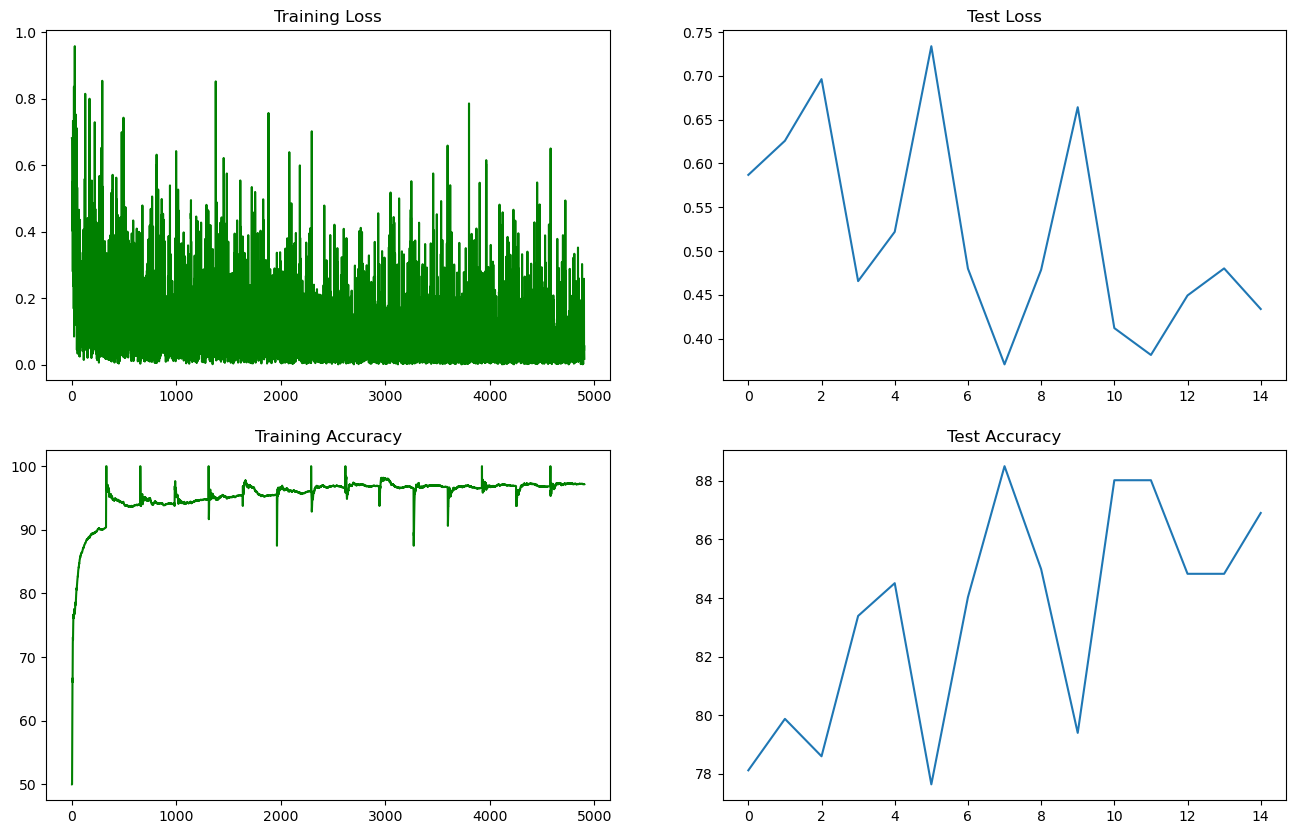

In [24]:
train_losses = [float(i.cpu().detach().numpy()) for i in train_losses]
train_acc    = [i for i in train_acc]
test_losses  = [i for i in test_losses]
test_acc     = [i for i in test_acc]

fig, axs = plt.subplots(2,2,figsize=(16,10))

axs[0, 0].plot(train_losses, color='green')
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc, color='green')
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(test_losses)
axs[0, 1].set_title("Test Loss")
axs[1, 1].plot(test_acc)
axs[1, 1].set_title("Test Accuracy")

plt.show()

We see that the model has improved a lot, even in terms of stability. But we can still further stabilize the model, more precisely, the training accuracy is quite high whereas the test accuracy is relatively low, a solution could be regularization (fighting against overfitting).

# 8. Fourth variation: L1 regularization

The final experiment adds an L1 penalty to the training objective.

If $L_{\mathrm{NLL}}(\theta)$ denotes the negative log-likelihood loss, the modified objective is

$$
L(\theta)
=
L_{\mathrm{NLL}}(\theta)
+
\lambda\|\theta\|_1,
$$

where

$$
\|\theta\|_1
=
\sum_j |\theta_j|.
$$

The L1 term penalizes large absolute parameter values and can encourage sparse solutions. From an optimization viewpoint, the gradient contribution is related to the sign of each parameter,

$$
\frac{\partial}{\partial\theta_j}
|\theta_j|
=
\operatorname{sign}(\theta_j)
\quad(\theta_j\neq0),
$$

with a subgradient at zero.

This connects the implementation directly to classical regularization and convex-analysis ideas: the network objective is non-convex because of the deep architecture, but the regularization term itself is the familiar L1 norm used in sparse estimation.

In [25]:
# Modified objective: NLL + lambda * L1(parameter norm).

def train(model, device, train_loader, optimizer, epoch, lambda1):
    model.train()
    pbar = tqdm(train_loader)
    correct = 0
    processed = 0
    for batch_idx, (data, target) in enumerate(pbar):
        # get data
        data, target = data.to(device), target.to(device)
       
        # Initialization of gradient
        optimizer.zero_grad()
       
        # prediction on data
        y_pred = model(data)
        
        # Calculating loss given the prediction
        loss = F.nll_loss(y_pred, target)
        l1 = 0
        for p in model.parameters():
            l1 = l1 + p.abs().sum()
        loss = loss + lambda1*l1
        train_losses.append(loss)
        
        # Backprop
        loss.backward()
        optimizer.step()
        
        # get the index of the log-probability corresponding to the max value
        pred = y_pred.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        processed += len(data)
        
        pbar.set_description(desc= f"Loss={loss.item()} Batch_id={batch_idx} Accuracy={100*correct/processed}")
        train_acc.append(100*correct/processed)

The metric arrays are reset again so that the final experiment has an independent history.

In [26]:
# Fresh metric containers for an independent experiment.
train_losses = []
test_losses  = []
train_acc    = []
test_acc     = []

Here the batch-normalized CNN is trained with

$$
\lambda=10^{-4}.
$$

The scheduler and SGD settings are retained. The only conceptual change is the addition of the L1 penalty to the objective, allowing us to ask whether explicit parameter regularization improves the generalization obtained with batch normalization.

In [27]:
# Final experiment: batch normalization + L1 regularization.
model = Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01,
momentum=0.9)
scheduler = StepLR(optimizer, step_size=6, gamma=0.5)

EPOCHS = 15
lambda1 = 0.0001
for epoch in range(EPOCHS):
    print("EPOCH:", epoch)
    train(model, device, train_loader, optimizer, epoch, lambda1)
    scheduler.step()
    print('current Learning Rate: ', optimizer.state_dict()["param_groups"][0]["lr"])
    test(model, device, test_loader)

EPOCH: 0


Loss=0.29612183570861816 Batch_id=326 Accuracy=91.13149847094802: 100%|█| 327/32


current Learning Rate:  0.01

Test set: Average loss: 0.5091, Accuracy: 534/626 (85.30%)

EPOCH: 1


Loss=0.16542178392410278 Batch_id=326 Accuracy=94.34250764525994: 100%|█| 327/32


current Learning Rate:  0.01

Test set: Average loss: 0.5868, Accuracy: 508/626 (81.15%)

EPOCH: 2


...

current Learning Rate:  0.0025

Test set: Average loss: 0.5185, Accuracy: 528/626 (84.35%)

EPOCH: 13


Loss=0.12151286005973816 Batch_id=326 Accuracy=97.09480122324159: 100%|█| 327/32


current Learning Rate:  0.0025

Test set: Average loss: 0.4434, Accuracy: 543/626 (86.74%)

EPOCH: 14


Loss=0.08298900723457336 Batch_id=326 Accuracy=97.11391437308869: 100%|█| 327/32


current Learning Rate:  0.0025

Test set: Average loss: 0.5686, Accuracy: 519/626 (82.91%)



The final learning curves summarize the effect of the fourth experiment.

In the recorded run, the test accuracy remains around **87.06%**. Notice that the training accuracy is substantially higher than the test accuracy; this gap is important evidence that the model still has room for improved generalization.

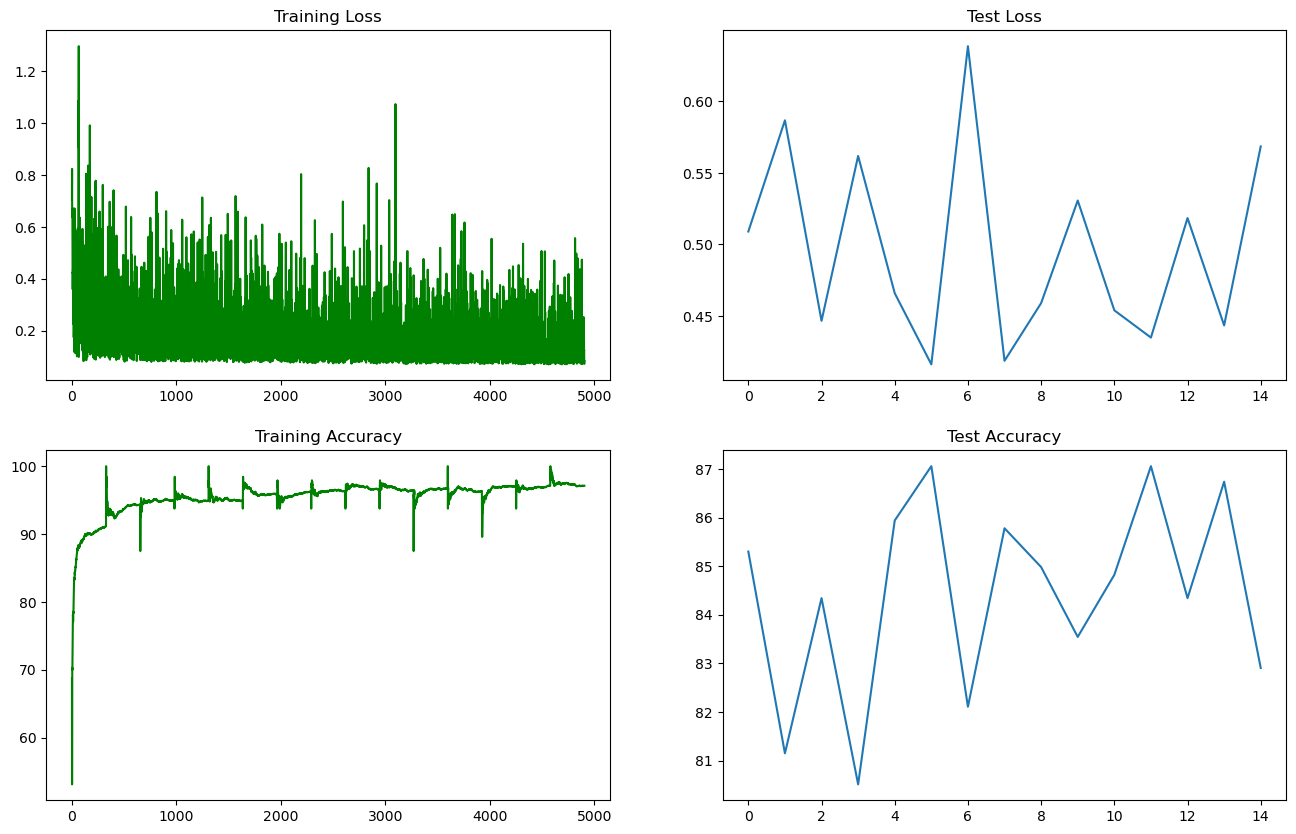

In [28]:
train_losses = [float(i.cpu().detach().numpy()) for i in train_losses]
train_acc    = [i for i in train_acc]
test_losses  = [i for i in test_losses]
test_acc     = [i for i in test_acc]

fig, axs = plt.subplots(2,2,figsize=(16,10))

axs[0, 0].plot(train_losses, color='green')
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc, color='green')
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(test_losses)
axs[0, 1].set_title("Test Loss")
axs[1, 1].plot(test_acc)
axs[1, 1].set_title("Test Accuracy")

plt.show()

## 9. Final experimental interpretation

The statement below should be read as **test accuracy**.

$$
\mathrm{Accuracy}
=
\frac{TP+TN}{TP+TN+FP+FN}.
$$

For the supplied experiment, the best recorded test accuracy is approximately **87.06%**.

The progression is informative:

| Experiment | Main change | Recorded test performance |
|---|---|---:|
| Baseline CNN | No augmentation / no BN | ~62.3% final |
| Data augmentation | Image-space regularization | ~82.0% final |
| Batch normalization | Internal activation normalization | ~85.0% best |
| Batch normalization + L1 | Explicit parameter regularization | ~87.06% best |


## Important limitations

This is an educational computer-vision project, **not a clinical diagnostic system**. A production medical-imaging model would require substantially more work, including patient-level data splitting, leakage checks, external validation, sensitivity/specificity, ROC-AUC, precision-recall analysis, calibration, subgroup analysis, uncertainty estimation, explainability, and clinical validation.

In particular, because the dataset is imbalanced, accuracy should not be used as the sole performance criterion.

## Mathematical perspective

The project can be viewed as the numerical study of a parameterized nonlinear map

$$
f_\theta:
\mathbb R^{3\times224\times224}
\longrightarrow
\mathbb R^2,
$$

where $\theta\in\mathbb R^p$ contains the trainable convolutional and normalization parameters. Training seeks an approximate minimizer of an empirical objective

$$
\min_{\theta}
\frac1N\sum_{i=1}^N
\ell(f_\theta(x_i),y_i)
+
\lambda\|\theta\|_1.
$$

The forward pass is a composition of linear operators, nonlinearities, and pooling maps; backpropagation computes derivatives of this composition using the chain rule; SGD then performs an iterative numerical optimization procedure.